In [73]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

nodes_df = pd.read_csv("./pre_processing_output/multi_label_nodes.csv")  # Dataset con nodi (proteine)
edges_df = pd.read_csv("./pre_processing_output/edges.csv")  # Dataset con interazioni proteina-proteina

nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(eval(x), dtype=torch.int))

G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))

edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.long)

data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
    edge_index=edges,  # Edge list
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes])  # Multilabel target
)

print(data)


Data(x=[179, 200], edge_index=[2, 666], y=[179, 2])


/tmp/ipykernel_16290/1861890349.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))


In [74]:
# Definizione del modello

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0):
        super(GCN, self).__init__()
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        
        self.dropout = dropout
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        # return F.sigmoid(x)
        return x # BCEWithLogitsLoss già applica la sigmoide
    
    def train_model(self, data, optimizer,criterion, epochs=200):
        self.train()
        loss_values = []
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            out = self.forward(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Applicazione della loss function
            loss.backward()  # Backpropagation
            optimizer.step()  # Aggiornamento pesi
            
            loss_values.append(loss.item())
            
            if epoch % 10 == 0:
                print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
        
        # grafico della loss
        plt.figure()
        plt.plot(range(epochs), loss_values, label='Training Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.legend()
        plt.show()


Epoch 0, Loss: 1.1407
Epoch 10, Loss: 0.6211
Epoch 20, Loss: 0.5507
Epoch 30, Loss: 0.5189
Epoch 40, Loss: 0.4929
Epoch 50, Loss: 0.4712
Epoch 60, Loss: 0.4507
Epoch 70, Loss: 0.4317
Epoch 80, Loss: 0.4124
Epoch 90, Loss: 0.3928
Epoch 100, Loss: 0.3731
Epoch 110, Loss: 0.3539
Epoch 120, Loss: 0.3372
Epoch 130, Loss: 0.3217
Epoch 140, Loss: 0.3061
Epoch 150, Loss: 0.2940
Epoch 160, Loss: 0.2828
Epoch 170, Loss: 0.2708
Epoch 180, Loss: 0.2630
Epoch 190, Loss: 0.2573
Epoch 200, Loss: 0.2487
Epoch 210, Loss: 0.2441
Epoch 220, Loss: 0.2323
Epoch 230, Loss: 0.2333
Epoch 240, Loss: 0.2216
Epoch 250, Loss: 0.2186
Epoch 260, Loss: 0.2126
Epoch 270, Loss: 0.2174
Epoch 280, Loss: 0.2039
Epoch 290, Loss: 0.2021
Epoch 300, Loss: 0.1980
Epoch 310, Loss: 0.1955
Epoch 320, Loss: 0.1950
Epoch 330, Loss: 0.1905
Epoch 340, Loss: 0.1940
Epoch 350, Loss: 0.1842
Epoch 360, Loss: 0.1818
Epoch 370, Loss: 0.1808
Epoch 380, Loss: 0.1797
Epoch 390, Loss: 0.1788
Epoch 400, Loss: 0.1774
Epoch 410, Loss: 0.1731
Epo

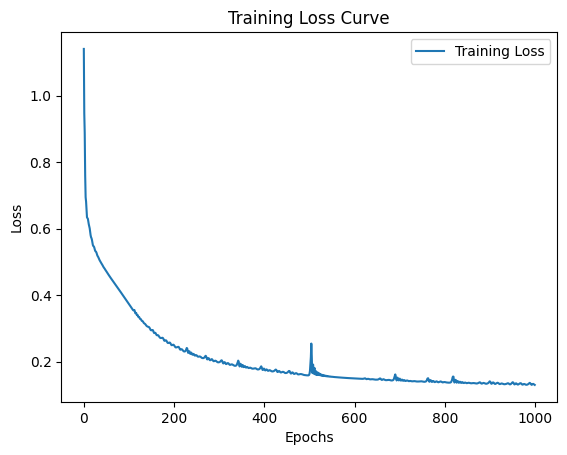

In [75]:
# Train-test split e addestramento
from torch.optim import Adam

num_nodes = data.x.shape[0]
train_mask = torch.rand(num_nodes) < 0.8  # 80% training, 20% test
test_mask = ~train_mask

data.train_mask = train_mask

model = GCN(in_channels=data.x.shape[1], hidden_channels=64, out_channels=data.y.shape[1])
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

model.train_model(data, optimizer, criterion=nn.BCEWithLogitsLoss(), epochs=1000)

In [76]:
# Metriche di valutazione

from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def test():
    model.eval()
    with torch.no_grad():
        out = torch.sigmoid(model(data.x, data.edge_index)) # Conversione dei logits in probabilità
        
        threshold = 0.5
        pred = (out[test_mask] > threshold).int()

        # Le metriche di scikit-learn vogliono i tensori di numpy
        y_true = data.y[test_mask].cpu().numpy()
        y_pred = pred.cpu().numpy()

        unique_preds, counts = torch.unique(pred, return_counts=True, dim=0)
        print("Label predette:", unique_preds.tolist(), "Numero di sample predetti per label:", counts.tolist())

        auc_ad = roc_auc_score(y_true[:, 0], y_pred[:, 0])
        auc_pd = roc_auc_score(y_true[:, 1], y_pred[:, 1])        
        f1 = f1_score(y_true, y_pred, average="macro")  # F1 macro per multilabel

        print(f"AUC AD: {auc_ad:.4f}, AUC PD: {auc_pd:.4f}, F1-Score: {f1:.4f}")

def plot_roc_curve(y_true, y_pred, class_names=["AD", "PD"]):
    plt.figure(figsize=(8,6))
    
    for i in range(2):  # Due classi (AD e PD)
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)  # Calcola l'AUC
        plt.plot(fpr, tpr, label=f'ROC {class_names[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')  # Linea diagonale random
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - GCN Model')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

Label predette: [[0, 0], [0, 1], [1, 0], [1, 1]] Numero di sample predetti per label: [1, 13, 11, 4]
AUC AD: 0.5192, AUC PD: 0.4736, F1-Score: 0.5227


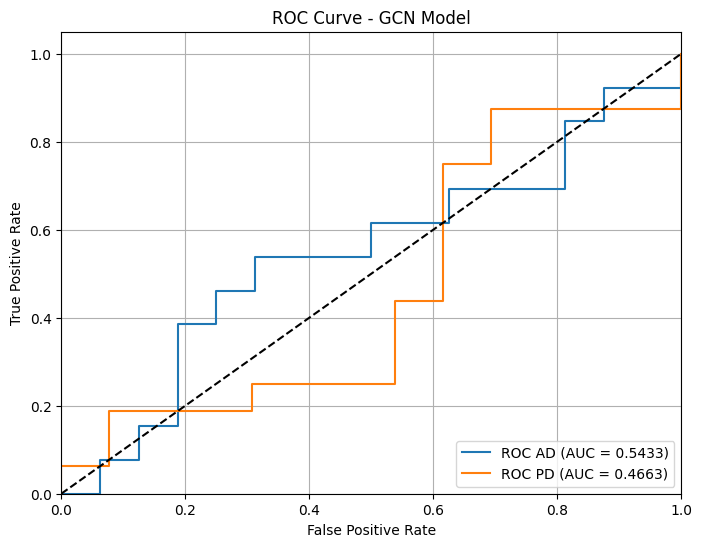

In [77]:
with torch.no_grad():
    out_test = model(data.x, data.edge_index)  # Predizioni della GCN
    y_pred = out_test[test_mask].numpy()  # Convertiamo in array numpy
    y_true = data.y[test_mask].numpy()  # Ground truth

test()
plot_roc_curve(y_true, y_pred)
